In [7]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "8"

In [8]:
import sys
sys.path.append(os.path.realpath('../../'))

In [9]:
from tqdm.auto import tqdm
from typing import List
import re
from typing import List, Tuple, Dict
from data.dataset import GraphDataset, ReimburseGraphDataset, DataAugmentationLevel, DialogNode, NodeType, StandardGraphDataset
import seaborn as sns
import pandas

In [10]:
DEVICE = 'cuda:0'
import torch

In [23]:
human_data_train = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/train_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
human_data_test = ReimburseGraphDataset('en/reimburse/test_graph.json', 'en/reimburse/test_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
generated_data_train_v1 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/chatgpt/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/chatgpt/train_questions_v1.json", resource_dir="../../resources/")
generated_data_train_v2 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/chatgpt/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/chatgpt/train_questions_v2.json", resource_dir="../../resources/")
generated_data_train_v3 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/chatgpt/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/chatgpt/train_questions_v3.json", resource_dir="../../resources/")

- not using synonyms
===== Dataset Statistics =====
- files:  en/reimburse/train_graph.json en/reimburse/train_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 279
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  7
- answer limit: 0  - maximum loaded:  1
- not using synonyms
===== Dataset Statistics =====
- files:  en/reimburse/test_graph.json en/reimburse/test_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 173
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  4
- answer limit: 0  - maximum loaded:  1
- Loading questions from  ../../resources/en/reimburse/generated/chatgpt/train_questions_v1.json
- not using synonyms
===== Dataset Statistics =====
- files:  en/reimburse/train_graph.json en/reimburse/generated/chatgpt/train_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 800
- load

## Question Lengths

In [11]:
def calculate_question_length(data: GraphDataset):
    question_length = []
    for node in tqdm(data.nodes_by_type[NodeType.INFO]):
        for question in node.questions:
            question_length.append(len(question.text.split(" ")))
    return question_length

In [22]:
question_length_human_train = calculate_question_length(human_data_train)
question_length_human_test = calculate_question_length(human_data_test)
question_length_generated_v1 = calculate_question_length(generated_data_train_v1)
question_length_generated_v2 = calculate_question_length(generated_data_train_v2)
question_length_generated_v3 = calculate_question_length(generated_data_train_v3)

100%|██████████| 59/59 [00:00<00:00, 29007.61it/s]


In [13]:
df = pandas.DataFrame(
    [{"source": "human_questions_train", "#words": length} for length in question_length_human_train] + 
    [{"source": "human_questions_test", "#words": length} for length in question_length_human_test] +
    [{"source": 'generated v1', "#words": length} for length in question_length_generated_v1] + 
    [{"source": 'generated v2', "#words": length} for length in question_length_generated_v2] +
    [{"source": 'generated v3', "#words": length} for length in question_length_generated_v3] 
)

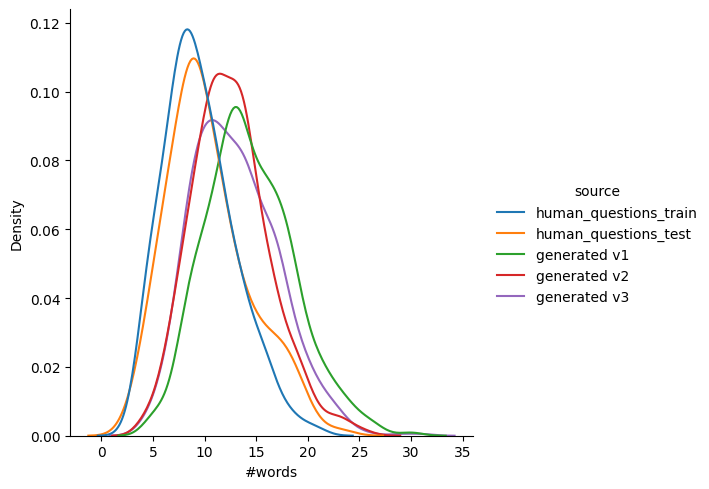

In [14]:
sns.displot(df.reset_index(drop=True), x="#words", kind="kde", hue='source', common_norm=False)

## Question Similarities

Two scenarios:

1. Pair-wise question similarity between all questions of a node (WITHIN the same dataset)
2. Pair-wise question similarity between the questions of a node from one dataset and the questions from another dataset

In [12]:
from data.dataset import Question
from sentence_transformers import SentenceTransformer, util

similarity_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=DEVICE, cache_folder = '/mount/arbeitsdaten/asr-2/vaethdk/resources/weights').to(DEVICE)

In [13]:
def calculate_similarity(questions_1: List[Question], questions_2: List[Question]):
    #Compute embedding for both lists
    embeddings1 = similarity_model.encode([q.text for q in questions_1], convert_to_tensor=True)
    embeddings2 = similarity_model.encode([q.text for q in questions_2], convert_to_tensor=True)

    #Compute pair-wise cosine-similarities -> #questions_1 x #questions_2
    cosine_scores = util.cos_sim(embeddings1, embeddings2)
    return cosine_scores.to("cpu")


#### 1. scenario: Pair-wise question similarity between all questions of a node (WITHIN the same dataset)

In [14]:
def within_dataset_similarity(dataset: GraphDataset) -> List[float]:
    similarities = []
    for node in tqdm(dataset.nodes_by_type[NodeType.INFO]):
        if len(node.questions) > 0:
            pariwise_sim = calculate_similarity(node.questions, node.questions)
            # ignore self-similarity (matrix diagnoal)
            # also: matrix is symmetric
            # --> only look at triangle above diagonal
            pariwise_sim = torch.triu(pariwise_sim, diagonal=1) # will set elements on and below diagonal to 0
            pariwise_sim = pariwise_sim.view(-1) # convert to list
            relevant_elements = pariwise_sim[pariwise_sim.nonzero()].view(-1) # extract nonzero entries
            similarities.extend(relevant_elements.tolist())     
    return similarities           

In [13]:
human_train_similarity = within_dataset_similarity(human_data_train)
human_test_similarity = within_dataset_similarity(human_data_test)
generated_similarity_v1 = within_dataset_similarity(generated_data_train_v1)
generated_similarity_v2 = within_dataset_similarity(generated_data_train_v2)
generated_similarity_v3 = within_dataset_similarity(generated_data_train_v3)

100%|██████████| 80/80 [00:04<00:00, 19.10it/s]


In [14]:
df = pandas.DataFrame(
    [{"source": "human_questions_train", "similarity": sim} for sim in human_train_similarity] + 
    [{"source": "human_questions_test", "similarity": sim} for sim in human_test_similarity] +
    [{"source": 'generated v1', "similarity": sim} for sim in generated_similarity_v1] + 
    [{"source": 'generated v2', "similarity": sim} for sim in generated_similarity_v2] +
    [{"source": 'generated v3', "similarity": sim} for sim in generated_similarity_v3]
)

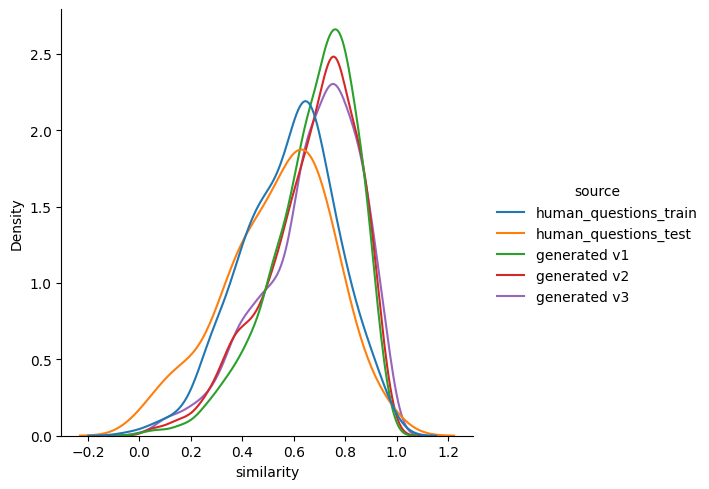

In [15]:
sns.displot(df.reset_index(drop=True), x="similarity", kind="kde", hue='source', common_norm=False)

- not using synonyms
===== Dataset Statistics =====
- files:  en/onboarding/train_graph.json en/onboarding/train_answers.json
- synonyms: False
- depth: 12  - degree: 9
- answers: 57
- questions: 141
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  4
- answer limit: 0  - maximum loaded:  1
- not using synonyms
===== Dataset Statistics =====
- files:  en/onboarding/test_graph.json en/onboarding/test_answers.json
- synonyms: False
- depth: 12  - degree: 9
- answers: 57
- questions: 117
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  3
- answer limit: 0  - maximum loaded:  1
- Loading questions from  ../../resources/en/onboarding/generated/chatgpt/train_questions_v2.json
- not using synonyms
===== Dataset Statistics =====
- files:  en/onboarding/train_graph.json en/onboarding/generated/chatgpt/train_answers.json
- synonyms: False
- depth: 12  - degree: 9
- answers: 70
- questions: 590
- 

100%|██████████| 59/59 [00:03<00:00, 17.09it/s]


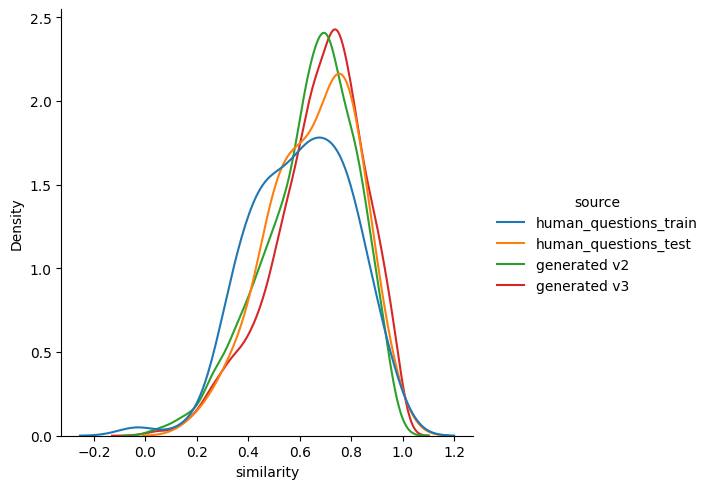

In [18]:
# ONBOARDING

onboarding_human_data_train = GraphDataset('en/onboarding/train_graph.json', 'en/onboarding/train_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
onboarding_human_data_test = GraphDataset('en/onboarding/test_graph.json', 'en/onboarding/test_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
onboarding_generated_data_train_v2 = StandardGraphDataset('en/onboarding/train_graph.json', 'en/onboarding/generated/chatgpt/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/onboarding/generated/chatgpt/train_questions_v2.json", resource_dir="../../resources/")
onboarding_generated_data_train_v3 = StandardGraphDataset('en/onboarding/train_graph.json', 'en/onboarding/generated/chatgpt/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/onboarding/generated/chatgpt/train_questions_v3.json", resource_dir="../../resources/")

onboarding_human_train_similarity = within_dataset_similarity(onboarding_human_data_train)
onboarding_human_test_similarity = within_dataset_similarity(onboarding_human_data_test)
onboarding_generated_similarity_v2 = within_dataset_similarity(onboarding_generated_data_train_v2)
onboarding_generated_similarity_v3 = within_dataset_similarity(onboarding_generated_data_train_v3)

onboarding_df = pandas.DataFrame(
    [{"source": "human_questions_train", "similarity": sim} for sim in onboarding_human_train_similarity] + 
    [{"source": "human_questions_test", "similarity": sim} for sim in onboarding_human_test_similarity] +
    [{"source": 'generated v2', "similarity": sim} for sim in onboarding_generated_similarity_v2] +
    [{"source": 'generated v3', "similarity": sim} for sim in onboarding_generated_similarity_v3]
)

sns.displot(onboarding_df.reset_index(drop=True), x="similarity", kind="kde", hue='source', common_norm=False)

#### 2. scenario: Pair-wise question similarity between the questions of a node from one dataset and the questions from another dataset

In [16]:
def between_dataset_similarity(dataset_1: GraphDataset, dataset_2: GraphDataset) -> List[float]:
    similarities = []
    for node_1 in tqdm(dataset_1.nodes_by_type[NodeType.INFO]):
        node_2 = dataset_2.nodes_by_key[node_1.key]
        if len(node_1.questions) > 0 and len(node_2.questions) > 0:
            pariwise_sim = calculate_similarity(node_1.questions, node_2.questions)
            pariwise_sim = pariwise_sim.view(-1) # convert to list
            similarities.extend(pariwise_sim.tolist())     
    return similarities           

In [25]:
sim_human_train_vs_human_test = between_dataset_similarity(human_data_train, human_data_test)

sim_human_train_vs_generated_v1 = between_dataset_similarity(human_data_train, generated_data_train_v1)
sim_human_train_vs_generated_v2 = between_dataset_similarity(human_data_train, generated_data_train_v2)
sim_human_train_vs_generated_v3 = between_dataset_similarity(human_data_train, generated_data_train_v3)

sim_human_test_vs_generated_v1 = between_dataset_similarity(human_data_test, generated_data_train_v1)
sim_human_test_vs_generated_v2 = between_dataset_similarity(human_data_test, generated_data_train_v2)
sim_human_test_vs_generated_v3 = between_dataset_similarity(human_data_test, generated_data_train_v3)

100%|██████████| 80/80 [00:03<00:00, 24.66it/s]


In [26]:
df = pandas.DataFrame(
    [{"source": "human(train) vs human(test)", "similarity": sim} for sim in sim_human_train_vs_human_test] + 
    [{"source": "human(train) vs generated v1", "similarity": sim} for sim in sim_human_train_vs_generated_v1] +
    [{"source": "human(train) vs generated v2", "similarity": sim} for sim in sim_human_train_vs_generated_v2] +
    [{"source": "human(train) vs generated v3", "similarity": sim} for sim in sim_human_train_vs_generated_v3]
    # [{"source": 'human(test) vs generated v1', "similarity": sim} for sim in sim_human_test_vs_generated_v1] + 
    # [{"source": 'human(test) vs generated v2', "similarity": sim} for sim in sim_human_test_vs_generated_v2] + 
    # [{"source": 'human(test) vs generated v3', "similarity": sim} for sim in sim_human_test_vs_generated_v3] 
)

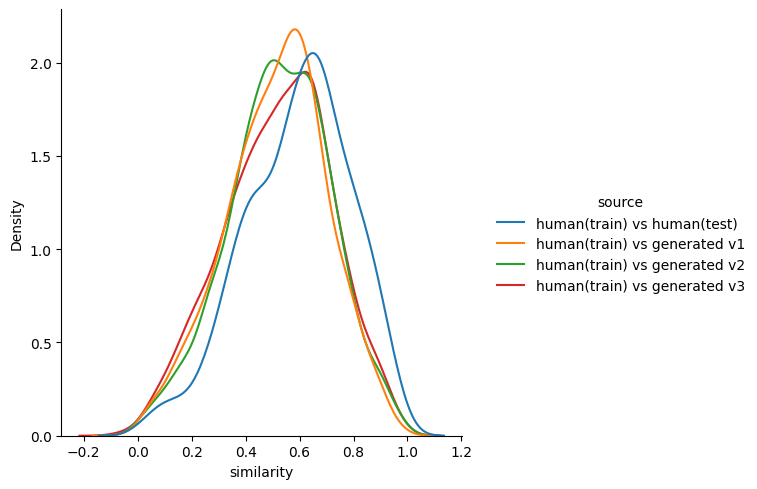

In [27]:
sns.displot(df.reset_index(drop=True), x="similarity", kind="kde", hue='source', common_norm=False)

100%|██████████| 59/59 [00:02<00:00, 23.45it/s]


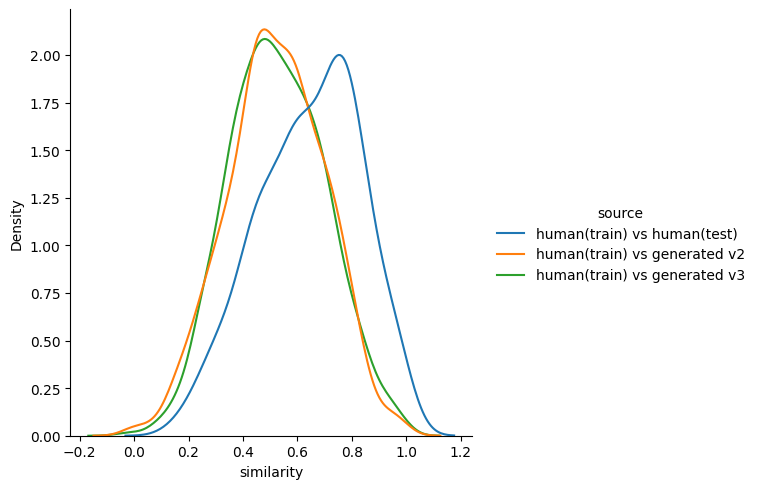

In [20]:
# onboard

onboarding_sim_human_train_vs_human_test = between_dataset_similarity(onboarding_human_data_train, onboarding_human_data_test)

onboarding_sim_human_train_vs_generated_v2 = between_dataset_similarity(onboarding_human_data_train, onboarding_generated_data_train_v2)
onboarding_sim_human_train_vs_generated_v3 = between_dataset_similarity(onboarding_human_data_train, onboarding_generated_data_train_v3)


onboarding_df = pandas.DataFrame(
    [{"source": "human(train) vs human(test)", "similarity": sim} for sim in onboarding_sim_human_train_vs_human_test] + 
    [{"source": "human(train) vs generated v2", "similarity": sim} for sim in onboarding_sim_human_train_vs_generated_v2] +
    [{"source": "human(train) vs generated v3", "similarity": sim} for sim in onboarding_sim_human_train_vs_generated_v3]
    # [{"source": 'human(test) vs generated v1', "similarity": sim} for sim in sim_human_test_vs_generated_v1] + 
    # [{"source": 'human(test) vs generated v2', "similarity": sim} for sim in sim_human_test_vs_generated_v2] + 
    # [{"source": 'human(test) vs generated v3', "similarity": sim} for sim in sim_human_test_vs_generated_v3] 
)

sns.displot(onboarding_df.reset_index(drop=True), x="similarity", kind="kde", hue='source', common_norm=False)

100%|██████████| 80/80 [00:03<00:00, 20.90it/s]


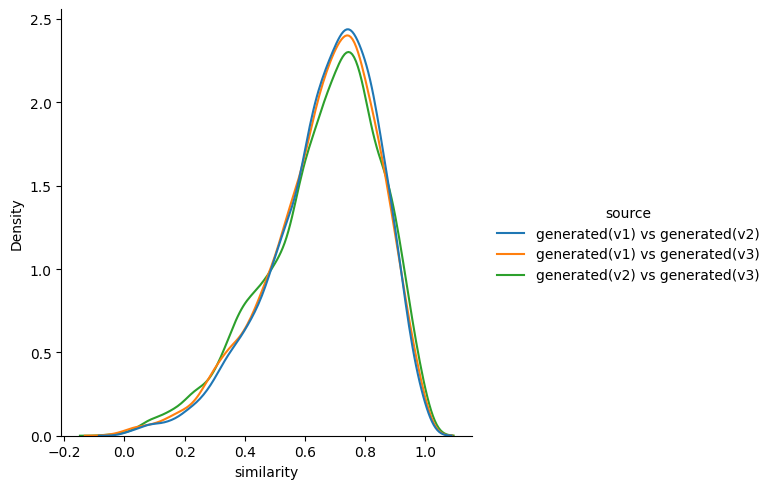

In [28]:
sim_generated_v1_vs_generated_v2 = between_dataset_similarity(generated_data_train_v1, generated_data_train_v2)
sim_generated_v1_vs_generated_v3 = between_dataset_similarity(generated_data_train_v1, generated_data_train_v3)
sim_generated_v2_vs_generated_v3 = between_dataset_similarity(generated_data_train_v2, generated_data_train_v3)

df = pandas.DataFrame(
    [{"source": 'generated(v1) vs generated(v2)', "similarity": sim} for sim in sim_generated_v1_vs_generated_v2] + 
    [{"source": 'generated(v1) vs generated(v3)', "similarity": sim} for sim in sim_generated_v1_vs_generated_v3] +
    [{"source": 'generated(v2) vs generated(v3)', "similarity": sim} for sim in sim_generated_v2_vs_generated_v3]
)

sns.displot(df.reset_index(drop=True), x="similarity", kind="kde", hue='source', common_norm=False)

# Conclusions

1. Generate shorter questions
2. Generate more diverse questions 